# Лабораторная работа № 2
**Студент:** Заречкин А. А., Б24-507. **Вариант:** 14.

Расстановка наблюдательных пунктов на графе для максимального покрытия при ограниченном числе пунктов.

Граф содержит 40 вершин и 80 рёбер; разрешены не более 5 пунктов. Пункт покрывает свою вершину и её соседей. Кодирование — бинарная строка, хранящаяся как целая битовая маска. Алгоритмы реализованы самостоятельно без готовых оптимизаторов.

Выполните все ячейки на CPU. Блокнот самостоятельный: при отсутствии `config.json` и `data/graph.json` используются встроенная конфигурация и генератор с seed 260514. Серии из 20 seed 42–61 сравнивают штраф с ремонтом, затем битовую мутацию с обменом. У каждого метода бюджет ровно 8000 оценок. Результаты сохраняются в `results`.


## Данные и дискретные операторы

In [1]:
import argparse
import csv
import itertools
import json
import math
import platform
import random
import statistics
import time
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Rectangle, Polygon


DEFAULT_CONFIG = {
    'student': 'Заречкин А. А.', 'group': 'Б24-507', 'variant': 14,
    'graph_seed': 260514, 'vertices': 40, 'extra_edges': 40, 'max_posts': 5,
    'coverage_radius': 1, 'population_size': 80, 'evaluation_budget': 8000,
    'tournament_size': 3, 'elitism': 2, 'crossover_rate': 0.9,
    'bit_mutation_probability': 0.025, 'swap_probability': 0.9,
    'penalty_coefficient': 41, 'seeds': list(range(42, 62)),
    'methods': ['penalty_bit', 'repair_bit', 'repair_swap', 'random_feasible']
}
LABELS = {'penalty_bit': 'Штраф + битовая', 'repair_bit': 'Ремонт + битовая',
          'repair_swap': 'Ремонт + обмен', 'random_feasible': 'Случайный поиск'}


def write_json(path, data):
    Path(path).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')


def write_csv(path, rows):
    with Path(path).open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def generate_graph(config):
    n = config['vertices']
    rng = random.Random(config['graph_seed'])
    edges = {tuple(sorted((i, (i + 1) % n))) for i in range(n)}
    available = [(i, j) for i in range(n) for j in range(i + 1, n) if (i, j) not in edges]
    edges.update(rng.sample(available, config['extra_edges']))
    return {'vertices': n, 'max_posts': config['max_posts'], 'coverage_radius': 1,
            'seed': config['graph_seed'], 'edges': [list(e) for e in sorted(edges)],
            'description': 'Связный неориентированный граф: цикл и случайные дополнительные рёбра'}


def neighborhoods(graph):
    n = graph['vertices']
    masks = [1 << i for i in range(n)]
    for i, j in graph['edges']:
        masks[i] |= 1 << j
        masks[j] |= 1 << i
    return masks


def selected(mask, n):
    return [i for i in range(n) if mask & (1 << i)]


def covered_mask(mask, masks):
    union = 0
    while mask:
        low = mask & -mask
        union |= masks[low.bit_length() - 1]
        mask ^= low
    return union


def coverage(mask, masks):
    return covered_mask(mask, masks).bit_count()


def feasible(mask, n, k):
    return isinstance(mask, int) and 0 <= mask < (1 << n) and mask.bit_count() <= k


def repair(mask, n, k, rng):
    active = selected(mask, n)
    if len(active) > k:
        for i in rng.sample(active, len(active) - k):
            mask ^= 1 << i
    return mask


def uniform_crossover(a, b, n, rng):
    selector = rng.getrandbits(n)
    return (a & selector) | (b & (((1 << n) - 1) ^ selector))


def bit_mutation(mask, n, probability, rng):
    for i in range(n):
        if rng.random() < probability:
            mask ^= 1 << i
    return mask


def swap_mutation(mask, n, k, probability, rng):
    if rng.random() >= probability:
        return mask
    active = selected(mask, n)
    inactive = [i for i in range(n) if not mask & (1 << i)]
    if not inactive or k == 0:
        return mask
    if len(active) < k:
        return mask | (1 << rng.choice(inactive))
    return mask ^ (1 << rng.choice(active)) ^ (1 << rng.choice(inactive))


def tournament(population, scores, size, rng):
    indices = rng.sample(range(len(population)), size)
    return population[max(indices, key=lambda i: scores[i])]

## Генетический алгоритм и допустимый случайный поиск

In [2]:
def run_search(graph, config, method, seed):
    rng = random.Random(seed)
    n, k = graph['vertices'], graph['max_posts']
    masks = neighborhoods(graph)
    budget, pop_size = config['evaluation_budget'], config['population_size']
    evaluations, valid_evaluations, best_value, best_mask = 0, 0, -1, 0
    history = []
    started = time.perf_counter()

    def evaluate(mask):
        nonlocal evaluations, valid_evaluations, best_value, best_mask
        value = coverage(mask, masks)
        evaluations += 1
        valid = feasible(mask, n, k)
        valid_evaluations += int(valid)
        if valid and value > best_value:
            best_value, best_mask = value, mask
        if evaluations == 1 or evaluations % 200 == 0 or evaluations == budget:
            history.append({'method': method, 'seed': seed, 'evaluations': evaluations,
                            'best_coverage': max(0, best_value)})
        return value - config['penalty_coefficient'] * max(0, mask.bit_count() - k)

    if method == 'random_feasible':
        for _ in range(budget):
            evaluate(sum(1 << i for i in rng.sample(range(n), k)))
    else:
        population = [0]
        for _ in range(pop_size - 1):
            mask = sum(1 << i for i in range(n) if rng.random() < k / n)
            population.append(repair(mask, n, k, rng) if method.startswith('repair') else mask)
        scores = [evaluate(mask) for mask in population]
        while evaluations < budget:
            elite = sorted(range(pop_size), key=lambda i: scores[i], reverse=True)[:config['elitism']]
            next_population = [population[i] for i in elite]
            next_scores = [scores[i] for i in elite]
            for _ in range(min(pop_size - len(elite), budget - evaluations)):
                a = tournament(population, scores, config['tournament_size'], rng)
                b = tournament(population, scores, config['tournament_size'], rng)
                child = uniform_crossover(a, b, n, rng) if rng.random() < config['crossover_rate'] else a
                if method.startswith('repair'):
                    child = repair(child, n, k, rng)
                if method == 'repair_swap':
                    child = swap_mutation(child, n, k, config['swap_probability'], rng)
                else:
                    child = bit_mutation(child, n, config['bit_mutation_probability'], rng)
                if method.startswith('repair'):
                    child = repair(child, n, k, rng)
                next_population.append(child)
                next_scores.append(evaluate(child))
            if len(next_population) == pop_size:
                population, scores = next_population, next_scores
    row = {'method': method, 'seed': seed, 'coverage': best_value,
           'coverage_percent': 100 * best_value / n, 'posts_count': best_mask.bit_count(),
           'posts': ' '.join(str(i + 1) for i in selected(best_mask, n)),
           'mask': best_mask, 'evaluations': evaluations, 'feasible_evaluations': valid_evaluations,
           'feasible_fraction': valid_evaluations / evaluations,
           'seconds': time.perf_counter() - started}
    return row, history

## Точный ориентир и жадная эвристика

In [3]:
def exact_reference(graph):
    masks = neighborhoods(graph)
    best, best_mask, count = -1, 0, 0
    started = time.perf_counter()
    for posts in itertools.combinations(range(graph['vertices']), graph['max_posts']):
        union = 0
        for i in posts:
            union |= masks[i]
        value = union.bit_count()
        count += 1
        if value > best:
            best, best_mask = value, sum(1 << i for i in posts)
    return {'coverage': best, 'mask': best_mask,
            'posts': [i + 1 for i in selected(best_mask, graph['vertices'])],
            'evaluations': count, 'seconds': time.perf_counter() - started,
            'reason': 'Покрытие монотонно: любое множество мощности меньше K можно дополнить до K'}


def greedy_reference(graph):
    masks, result, evaluations = neighborhoods(graph), 0, 0
    for _ in range(graph['max_posts']):
        choices = []
        for i in range(graph['vertices']):
            if not result & (1 << i):
                choices.append((coverage(result | (1 << i), masks), -i))
                evaluations += 1
        _, negative_i = max(choices)
        result |= 1 << (-negative_i)
    return {'coverage': coverage(result, masks), 'mask': result,
            'posts': [i + 1 for i in selected(result, graph['vertices'])], 'evaluations': evaluations}


def solution_details(graph, row):
    masks = neighborhoods(graph)
    mask = row['mask']
    union = covered_mask(mask, masks)
    return {**row, 'selected_vertices': [i + 1 for i in selected(mask, graph['vertices'])],
            'covered_vertices': [i + 1 for i in selected(union, graph['vertices'])],
            'uncovered_vertices': [i + 1 for i in range(graph['vertices']) if not union & (1 << i)],
            'per_post': [{'post': i + 1, 'covers': [j + 1 for j in selected(masks[i], graph['vertices'])]}
                         for i in selected(mask, graph['vertices'])]}


def create_examples(graph):
    n, k = graph['vertices'], graph['max_posts']
    examples = [('valid_small', (1 << 0) | (1 << (n // 4))), ('valid_limit', (1 << k) - 1),
                ('invalid_one_extra', (1 << (k + 1)) - 1), ('invalid_all', (1 << n) - 1)]
    return [{'name': name, 'posts': [i + 1 for i in selected(mask, n)], 'mask': mask,
             'count': mask.bit_count(), 'feasible': feasible(mask, n, k),
             'violation': max(0, mask.bit_count() - k), 'coverage': coverage(mask, neighborhoods(graph))}
            for name, mask in examples]

## Графики и блок схема

In [4]:
def draw_flowchart(path):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    blocks = [(5, 9.3, 'Граф, параметры и seed'), (5, 8, 'Инициализация бинарной популяции'),
              (5, 6.7, 'Оценка покрытия и ограничений\nОбновление лучшего допустимого решения'),
              (5, 3.7, 'Турнир → равномерный кроссовер\nМутация → ремонт или штраф'),
              (5, 2.3, 'Оценка потомков и элитизм'), (8, 5.2, 'Сохранение\nрезультата')]
    for x, y, label in blocks:
        width = 2.6 if x == 8 else 6
        ax.add_patch(Rectangle((x - width / 2, y - 0.42), width, 0.84, fill=False, linewidth=1.3))
        ax.text(x, y, label, ha='center', va='center', fontsize=10)
    ax.add_patch(Polygon([(5, 5.9), (6.6, 5.2), (5, 4.5), (3.4, 5.2)], fill=False))
    ax.text(5, 5.2, 'Бюджет исчерпан?', ha='center', va='center', fontsize=10)
    for a, b in [((5, 8.88), (5, 8.42)), ((5, 7.58), (5, 7.12)),
                 ((5, 6.28), (5, 5.9)), ((5, 4.5), (5, 4.12)),
                 ((5, 3.28), (5, 2.72)), ((6.6, 5.2), (6.7, 5.2))]:
        ax.add_patch(FancyArrowPatch(a, b, arrowstyle='->', mutation_scale=14))
    ax.plot([5, 5, 1, 1, 3.4], [1.88, 1.3, 1.3, 5.2, 5.2], color='black', linewidth=1)
    ax.add_patch(FancyArrowPatch((3.1, 5.2), (3.4, 5.2), arrowstyle='->', mutation_scale=14))
    ax.text(5.15, 4.25, 'Нет', fontsize=9)
    ax.text(6.6, 5.45, 'Да', fontsize=9)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.close(fig)


def plot_results(graph, config, rows, histories, optimum, best, out):
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})
    fig, ax = plt.subplots(figsize=(9, 5))
    for method in config['methods']:
        grouped = {}
        for h in histories:
            if h['method'] == method:
                grouped.setdefault(h['evaluations'], []).append(h['best_coverage'])
        xs = sorted(grouped)
        means = [statistics.mean(grouped[x]) for x in xs]
        line, = ax.plot(xs, means, label=LABELS[method])
        ax.fill_between(xs, [min(grouped[x]) for x in xs], [max(grouped[x]) for x in xs],
                        alpha=0.12, color=line.get_color())
    ax.axhline(optimum['coverage'], color='black', linestyle='--', label='Точный максимум')
    ax.set(xlabel='Вычисления целевой функции', ylabel='Лучшее допустимое покрытие')
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right', fontsize=9)
    fig.tight_layout()
    fig.savefig(out / 'convergence.png', dpi=180)
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot([[r['coverage'] for r in rows if r['method'] == m] for m in config['methods']],
               tick_labels=[LABELS[m] for m in config['methods']])
    ax.axhline(optimum['coverage'], color='black', linestyle='--', label='Точный максимум')
    ax.set_ylabel('Покрытые вершины после 8000 оценок')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out / 'comparison.png', dpi=180)
    plt.close(fig)
    n = graph['vertices']
    coords = [(math.cos(2 * math.pi * i / n), math.sin(2 * math.pi * i / n)) for i in range(n)]
    mask, union = best['mask'], covered_mask(best['mask'], neighborhoods(graph))
    fig, ax = plt.subplots(figsize=(8, 8))
    for i, j in graph['edges']:
        ax.plot([coords[i][0], coords[j][0]], [coords[i][1], coords[j][1]], color='#bbbbbb', alpha=0.5, linewidth=0.7)
    for i, (x, y) in enumerate(coords):
        color = '#173d6b' if mask & (1 << i) else '#c5dced' if union & (1 << i) else '#e9c2b8'
        ax.scatter(x, y, s=350, c=color, edgecolor='black', linewidth=0.8, zorder=3)
        ax.text(x, y, str(i + 1), ha='center', va='center', fontsize=9,
                color='white' if mask & (1 << i) else 'black', zorder=4)
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
               for c, l in [('#173d6b', 'Наблюдательный пункт'), ('#c5dced', 'Покрытая вершина'),
                            ('#e9c2b8', 'Непокрытая вершина')]]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=1)
    ax.set_aspect('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.axis('off')
    fig.tight_layout()
    fig.savefig(out / 'best_solution.png', dpi=180, bbox_inches='tight')
    plt.close(fig)
    draw_flowchart(out / 'flowchart.png')

## Проверка параметров и проведение эксперимента

In [5]:
def validate_config(config, graph):
    n, k = graph['vertices'], graph['max_posts']
    if not 0 < k < n or graph['coverage_radius'] != 1:
        raise ValueError('Требуется 0 < K < n и радиус покрытия 1')
    if config['population_size'] < 30 or config['evaluation_budget'] < config['population_size']:
        raise ValueError('Недостаточный размер популяции или бюджет')
    if not 0 < config['elitism'] < config['population_size']:
        raise ValueError('Некорректный элитизм')
    if not 1 <= config['tournament_size'] <= config['population_size']:
        raise ValueError('Некорректный турнир')
    if config['penalty_coefficient'] <= n:
        raise ValueError('Штраф должен превышать максимальное покрытие')
    if not config['seeds'] or len(set(config['seeds'])) != len(config['seeds']):
        raise ValueError('Seed должны быть различны')
    for key in ['crossover_rate', 'bit_mutation_probability', 'swap_probability']:
        if not 0 <= config[key] <= 1:
            raise ValueError('Вероятности должны принадлежать [0, 1]')
    if set(config['methods']) - set(LABELS):
        raise ValueError('Неизвестный метод')
    for i, j in graph['edges']:
        if not 0 <= i < j < n:
            raise ValueError('Некорректное ребро')


def experiment(config=None, graph=None, output_dir='results'):
    config = dict(DEFAULT_CONFIG) if config is None else config
    graph = generate_graph(config) if graph is None else graph
    validate_config(config, graph)
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    write_json(out / 'config_used.json', config)
    write_json(out / 'graph_used.json', graph)
    exact, greedy = exact_reference(graph), greedy_reference(graph)
    rows, histories = [], []
    for method in config['methods']:
        for seed in config['seeds']:
            row, history = run_search(graph, config, method, seed)
            rows.append(row)
            histories.extend(history)
        print(f'{method}: {len(config["seeds"])} запусков выполнено', flush=True)
    summaries = []
    for method in config['methods']:
        subset = [r for r in rows if r['method'] == method]
        values = [r['coverage'] for r in subset]
        summaries.append({'method': method, 'runs': len(values), 'best': max(values),
                          'mean': statistics.mean(values), 'median': statistics.median(values),
                          'std': statistics.stdev(values) if len(values) > 1 else 0,
                          'worst': min(values), 'optimal_runs': sum(v == exact['coverage'] for v in values),
                          'feasible_fraction_mean': statistics.mean(r['feasible_fraction'] for r in subset),
                          'mean_seconds': statistics.mean(r['seconds'] for r in subset),
                          'evaluations_per_run': config['evaluation_budget']})
    best = max((r for r in rows if r['method'] != 'random_feasible'), key=lambda r: r['coverage'])
    paired = []
    for left, right in [('penalty_bit', 'repair_bit'), ('repair_bit', 'repair_swap')]:
        for seed in config['seeds']:
            a = next(r for r in rows if r['method'] == left and r['seed'] == seed)
            b = next(r for r in rows if r['method'] == right and r['seed'] == seed)
            paired.append({'left': left, 'right': right, 'seed': seed, 'difference_right_minus_left': b['coverage'] - a['coverage']})
    write_csv(out / 'results.csv', rows)
    write_csv(out / 'history.csv', histories)
    write_csv(out / 'summary.csv', summaries)
    write_csv(out / 'paired_comparison.csv', paired)
    write_json(out / 'exact_reference.json', exact)
    write_json(out / 'greedy_reference.json', greedy)
    write_json(out / 'examples.json', create_examples(graph))
    write_json(out / 'best_solution.json', solution_details(graph, best))
    write_csv(out / 'best_solution.csv', [{'post': p['post'], 'covered_vertices': ' '.join(map(str, p['covers']))}
                                         for p in solution_details(graph, best)['per_post']])
    write_json(out / 'environment.json', {'python': platform.python_version(), 'matplotlib': matplotlib.__version__})
    plot_results(graph, config, rows, histories, exact, best, out)
    return {'summary': summaries, 'best': solution_details(graph, best), 'exact': exact, 'greedy': greedy}

## Запуск всех 80 экспериментов
Полный перебор используется только как независимая проверка максимума и не передаёт решения в ГА. Жадная эвристика — дополнительный ориентир; сравнение с равным бюджетом выполняется со случайным допустимым поиском.

In [6]:
config_path = Path('config.json')
graph_path = Path('data/graph.json')
config = json.loads(config_path.read_text(encoding='utf-8')) if config_path.exists() else dict(DEFAULT_CONFIG)
graph = json.loads(graph_path.read_text(encoding='utf-8')) if graph_path.exists() else generate_graph(config)
result = experiment(config, graph, 'results')
print('Метод                 Лучший  Средний  Медиана  СКО    Худший  Оптимум')
for row in result['summary']:
    print(f"{row['method']:21s} {row['best']:6d} {row['mean']:8.2f} {row['median']:8.1f} {row['std']:6.3f} {row['worst']:7d} {row['optimal_runs']:6d}/20")
print('Точный максимум:', result['exact']['coverage'])
print('Жадный ориентир:', result['greedy']['coverage'])
print('Пункты:', result['best']['selected_vertices'])
print('Непокрытые вершины:', result['best']['uncovered_vertices'])

penalty_bit: 20 запусков выполнено
repair_bit: 20 запусков выполнено
repair_swap: 20 запусков выполнено
random_feasible: 20 запусков выполнено
Метод                 Лучший  Средний  Медиана  СКО    Худший  Оптимум
penalty_bit               30    29.65     30.0  0.875      27     17/20
repair_bit                30    30.00     30.0  0.000      30     20/20
repair_swap               30    30.00     30.0  0.000      30     20/20
random_feasible           29    27.75     28.0  0.639      27      0/20
Точный максимум: 30
Жадный ориентир: 30
Пункты: [6, 10, 17, 33, 40]
Непокрытые вершины: [4, 12, 19, 22, 23, 26, 28, 35, 36, 37]


## Примеры и проверка итоговых файлов
Проверяются число оценок, допустимость, соответствие покрытия точному ориентиру и отсутствие превышения бюджета.

In [7]:
for example in create_examples(graph):
    print(example)
with Path('results/results.csv').open(encoding='utf-8') as f:
    rows = list(csv.DictReader(f))
assert len(rows) == len(config['seeds']) * len(config['methods'])
for row in rows:
    assert int(row['evaluations']) == config['evaluation_budget']
    assert feasible(int(row['mask']), graph['vertices'], graph['max_posts'])
    assert coverage(int(row['mask']), neighborhoods(graph)) == int(row['coverage'])
    assert int(row['coverage']) <= result['exact']['coverage']
print('Все итоговые решения допустимы. Бюджеты и покрытие проверены.')

{'name': 'valid_small', 'posts': [1, 11], 'mask': 1025, 'count': 2, 'feasible': True, 'violation': 0, 'coverage': 8}
{'name': 'valid_limit', 'posts': [1, 2, 3, 4, 5], 'mask': 31, 'count': 5, 'feasible': True, 'violation': 0, 'coverage': 14}
{'name': 'invalid_one_extra', 'posts': [1, 2, 3, 4, 5, 6], 'mask': 63, 'count': 6, 'feasible': False, 'violation': 1, 'coverage': 16}
{'name': 'invalid_all', 'posts': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40], 'mask': 1099511627775, 'count': 40, 'feasible': False, 'violation': 35, 'coverage': 40}
Все итоговые решения допустимы. Бюджеты и покрытие проверены.


## Визуализация результатов
Линии показывают среднее лучшее допустимое покрытие по 20 seed, полупрозрачные области — минимум и максимум. На схеме графа показаны выбранные пункты, покрытые и непокрытые вершины.

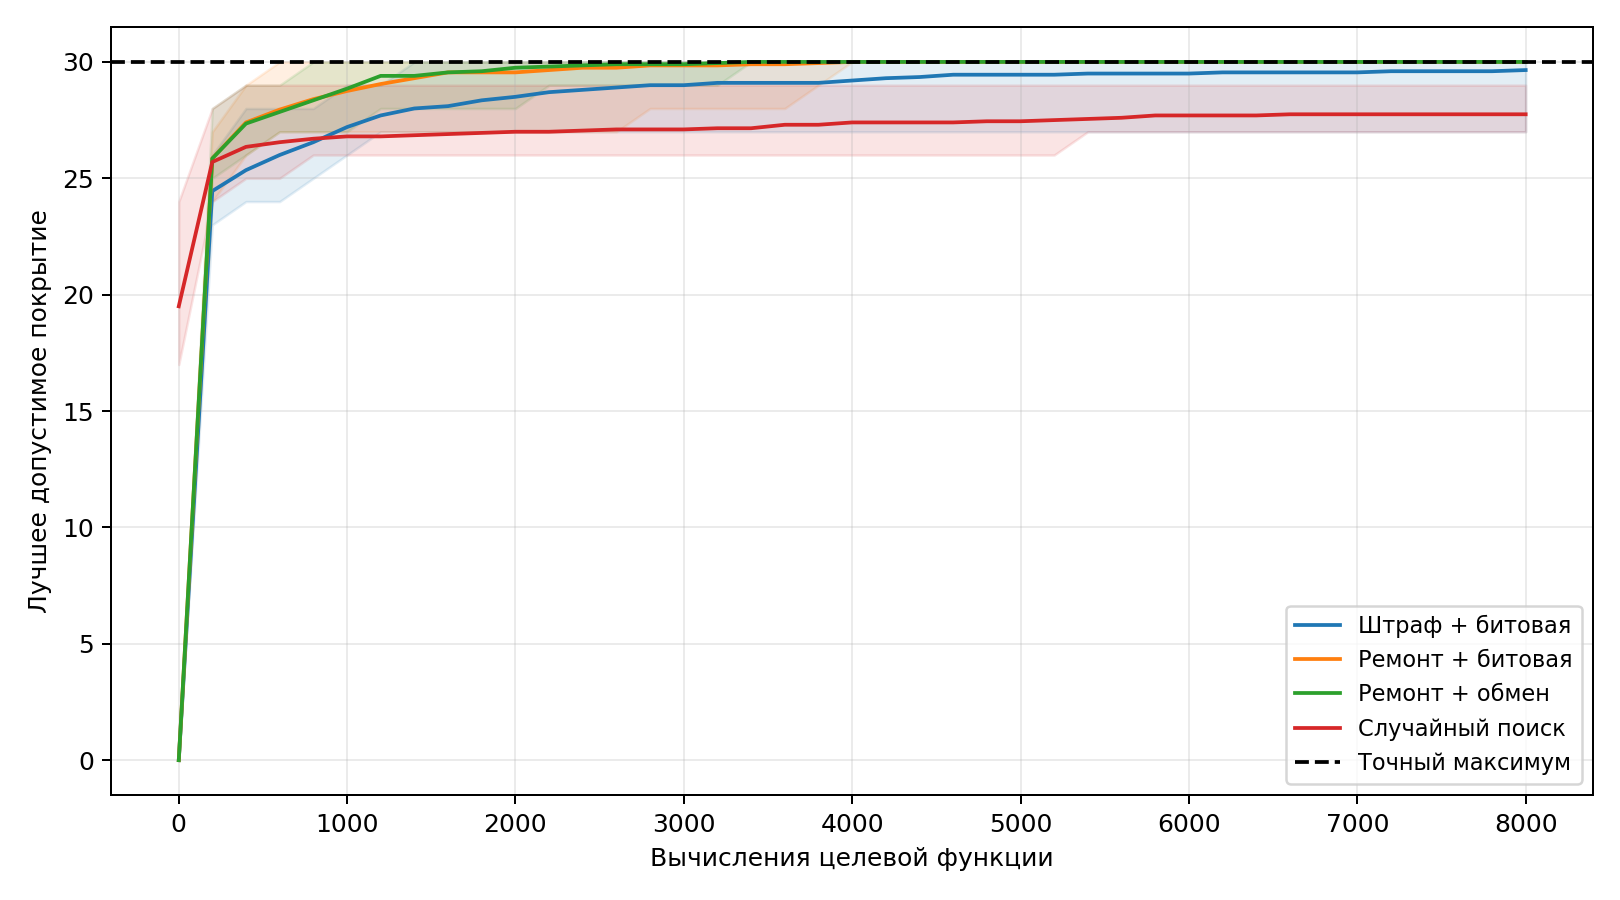

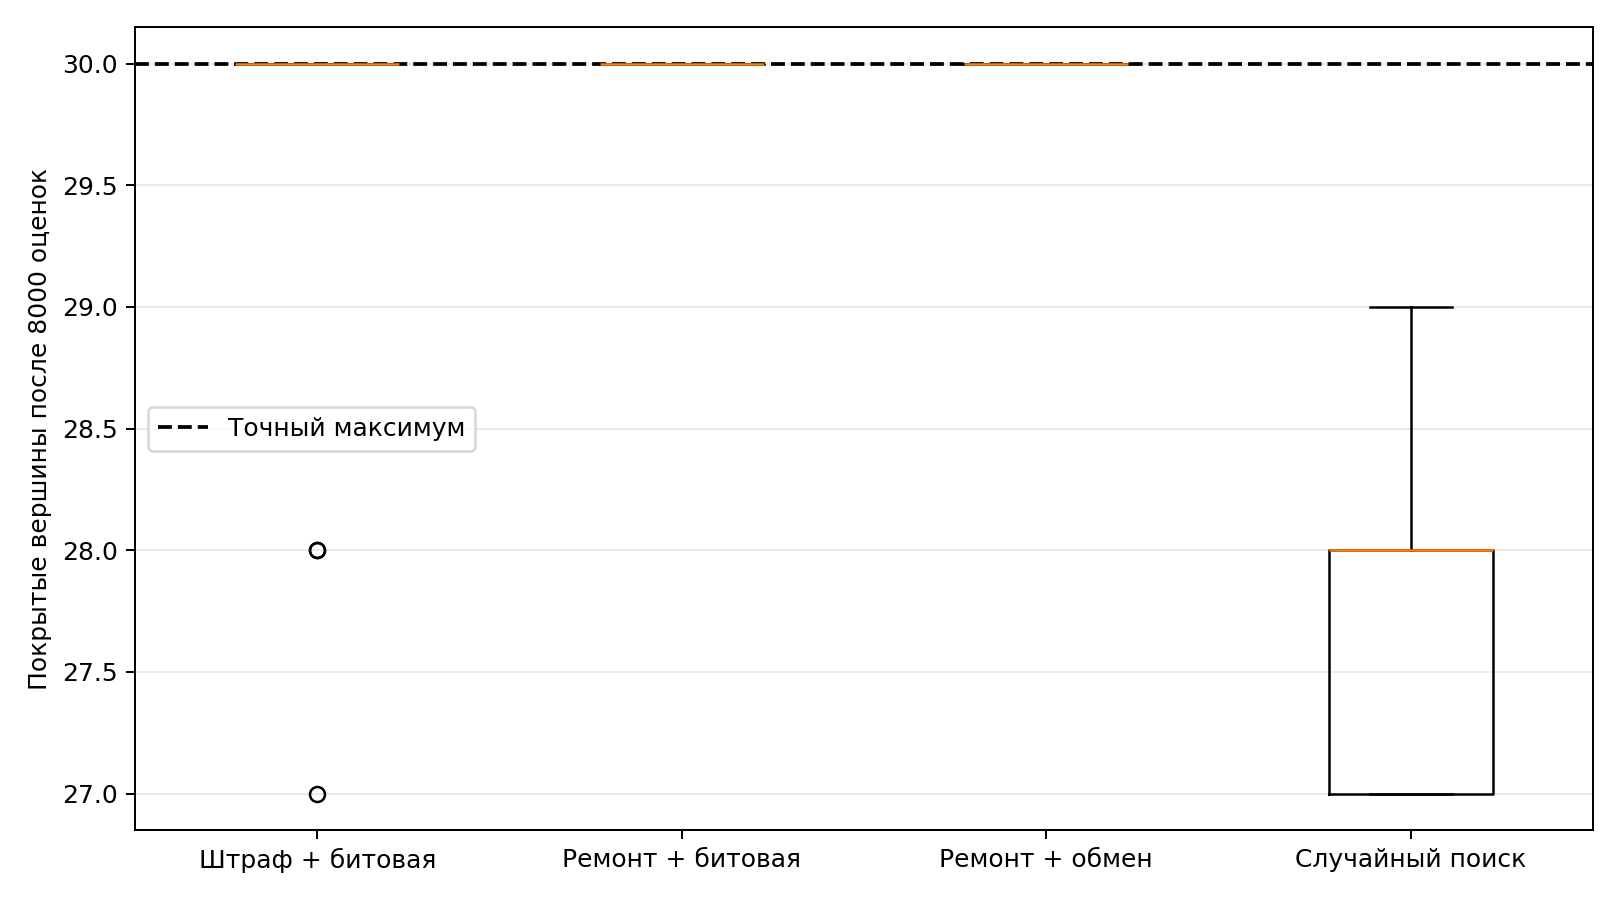

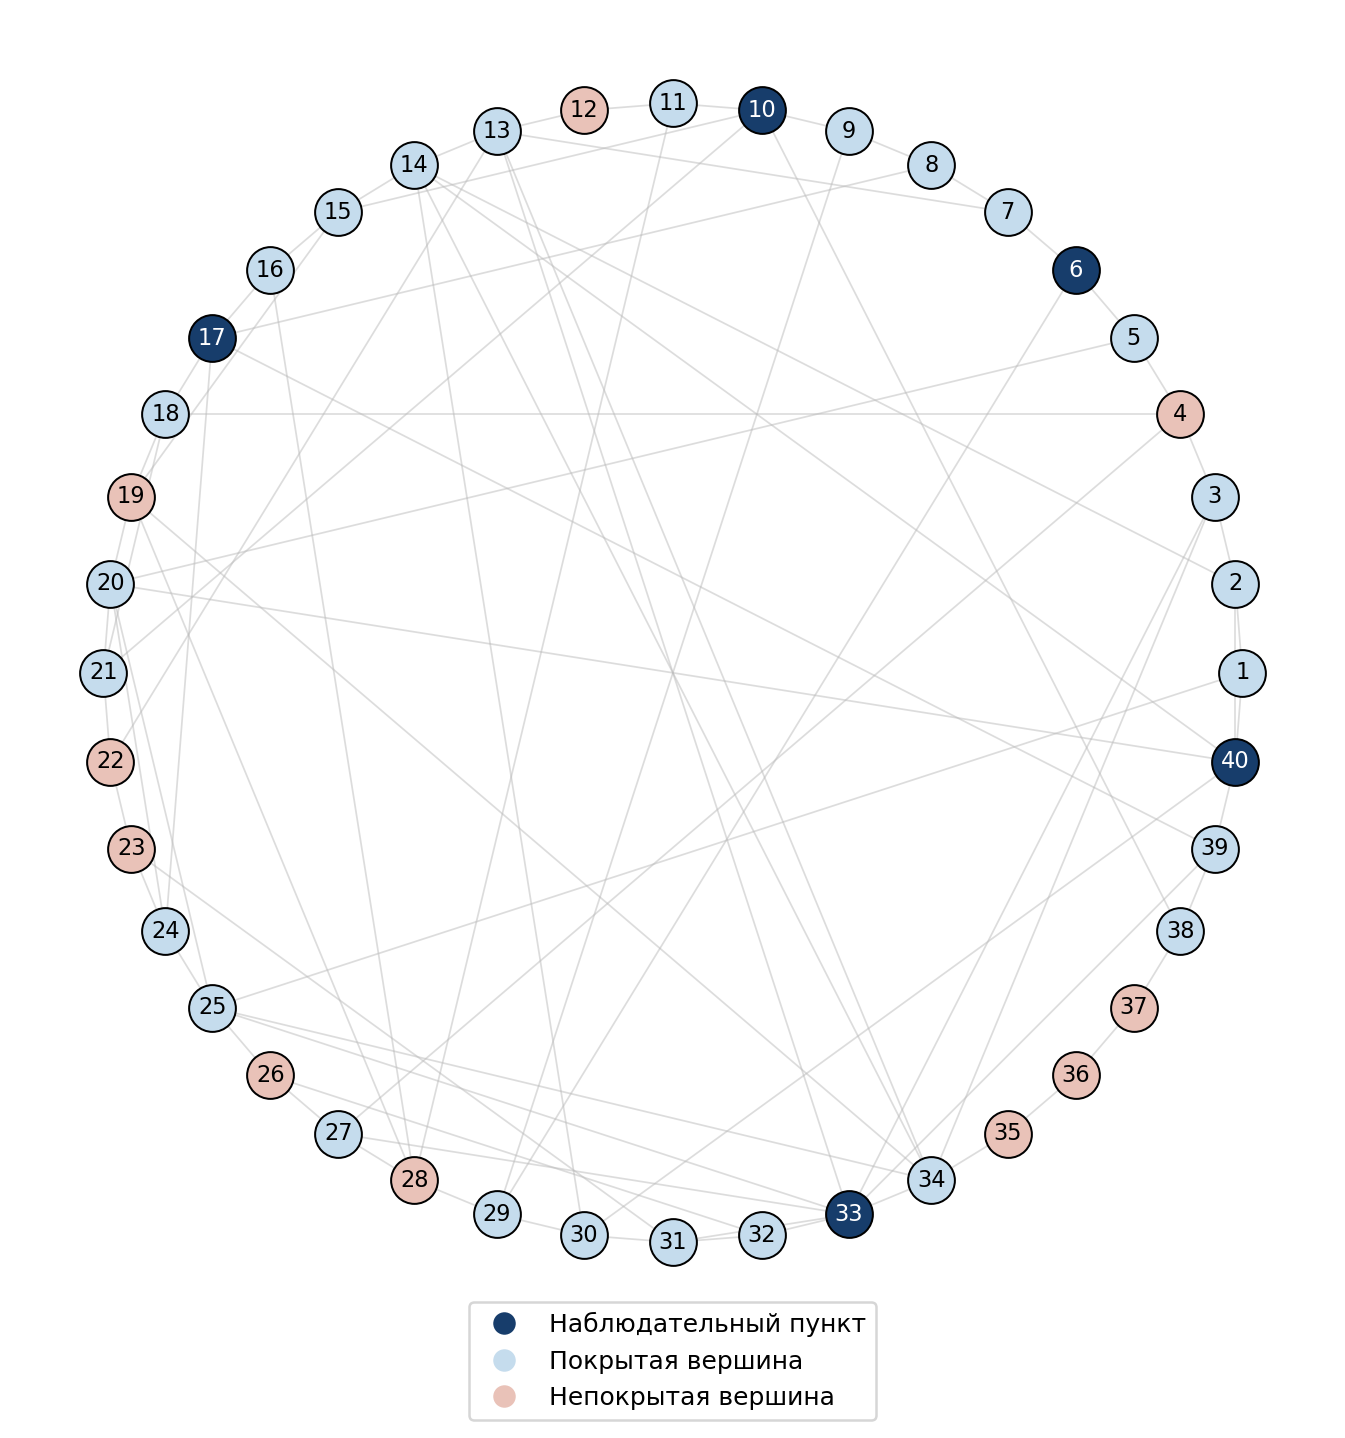

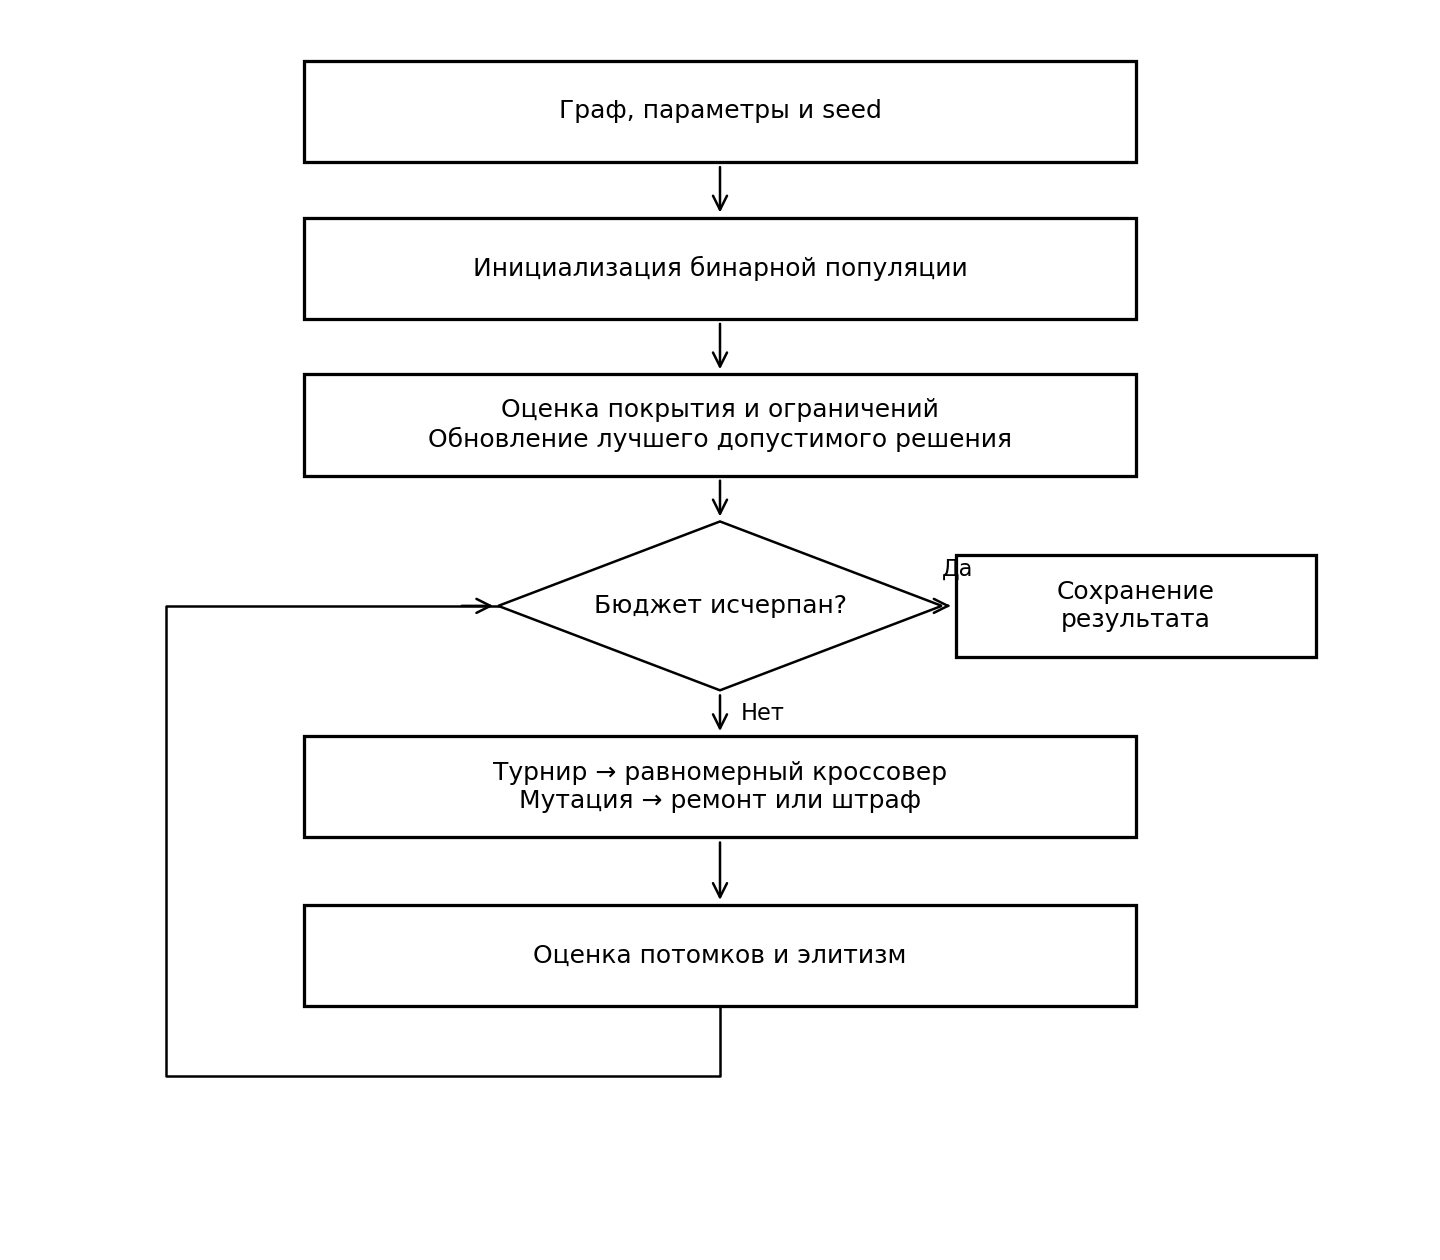

In [8]:
from IPython.display import Image, display
for filename in ['convergence.png', 'comparison.png', 'best_solution.png', 'flowchart.png']:
    display(Image(filename=str(Path('results') / filename)))

## Вывод
Ремонт обеспечивает допустимость всех оцениваемых особей и в данной серии дал оптимум в 20 из 20 запусков для обоих операторов. Штраф нашёл оптимум в 17 из 20 запусков. Случайный допустимый поиск не достиг максимума. Обмен немного быстрее на раннем участке, однако итоговое качество двух операторов одинаково. Жадная эвристика также достигает максимума с меньшими затратами, поэтому преимущество ГА перед ней для этого экземпляра не установлено. Точный перебор доказывает максимум 30 вершин, а частота его достижения ГА является экспериментальным результатом.